<a href="https://www.kaggle.com/code/vedikagupta0/catboost-lgbm-xgb-churn-prediction-0-912?scriptVersionId=305518483" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [141]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from catboost import CatBoostClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
df_og = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
tf = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [142]:
df_og.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [143]:
df2.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [144]:
id_col = ['id', 'customerID']

In [145]:
df_og.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [146]:
df2.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


##### no null values were observed

In [147]:
df2.shape

(7043, 21)

In [148]:
df_og.shape

(594194, 21)

In [149]:
df = pd.concat([df_og, df2], axis=0)

In [150]:
df.drop(columns=id_col, inplace=True)

In [151]:
df.shape

(601237, 20)

### mapped senior citizen to general binary format following the dataset format.

In [152]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})
df_og['SeniorCitizen'] = df_og['SeniorCitizen'].map({0:'No', 1:'Yes'})
tf['SeniorCitizen'] = tf['SeniorCitizen'].map({0:'No', 1:'Yes'})

### since less cardinality exists, we can have a look at the unique values each feature possess.

In [153]:
for col in df.columns:
    print(f"{col} --> {df[col].unique()}")
    print()

gender --> ['Male' 'Female']

SeniorCitizen --> ['No' 'Yes']

Partner --> ['Yes' 'No']

Dependents --> ['Yes' 'No']

tenure --> [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32
  0]

PhoneService --> ['Yes' 'No']

MultipleLines --> ['No' 'Yes' 'No phone service']

InternetService --> ['DSL' 'Fiber optic' 'No']

OnlineSecurity --> ['Yes' 'No' 'No internet service']

OnlineBackup --> ['No' 'Yes' 'No internet service']

DeviceProtection --> ['Yes' 'No' 'No internet service']

TechSupport --> ['Yes' 'No' 'No internet service']

StreamingTV --> ['No' 'Yes' 'No internet service']

StreamingMovies --> ['No' 'Yes' 'No internet service']

Contract --> ['One year' 'Two year' 'Month-to-month']

PaperlessBilling --> ['Yes' 'No']

PaymentMethod --> ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automa

In [154]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',0).astype(float)
df['is_auto_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)
df['paperless_autopay'] = ((df['PaperlessBilling'] == 'Yes') & (df['is_auto_payment'] == 1)).astype(int)

df['high_monthlycharges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].mean()).astype(int)
df['high_totalcharges'] = (df['TotalCharges'] > df['TotalCharges'].mean()).astype(int)

tenure_75 = df['tenure'].quantile(0.75)
df['high_tenure'] = (df['tenure'] > tenure_75).astype(int)

df['is_male_senior'] = ((df['gender'] == 'Male') & (df['SeniorCitizen'] == 'Yes')).astype(int)

def feature_streaming_internet_phone_all_true(df):
    return (
        (df['StreamingTV'] == 'Yes') &
        (df['StreamingMovies'] == 'Yes') &
        (df['InternetService'].isin(['DSL', 'Fiber optic'])) &
        (df['PhoneService'] == 'Yes')
    ).astype(int)


def feature_support_bundle_all_true(df):
    return (
        (df['DeviceProtection'] == 'Yes') &
        (df['OnlineBackup'] == 'Yes') &
        (df['OnlineSecurity'] == 'Yes') &
        (df['TechSupport'] == 'Yes')
    ).astype(int)

df['feat_streaming_internet_phone'] = feature_streaming_internet_phone_all_true(df)
df['feat_support_bundle'] = feature_support_bundle_all_true(df)

In [155]:
tf['TotalCharges'] = tf['TotalCharges'].replace('',0).astype(float)
tf['is_auto_payment'] = tf['PaymentMethod'].str.contains('automatic').astype(int)
tf['paperless_autopay'] = ((tf['PaperlessBilling'] == 'Yes') & (tf['is_auto_payment'] == 1)).astype(int)

tf['high_monthlycharges'] = (tf['MonthlyCharges'] > tf['MonthlyCharges'].mean()).astype(int)
tf['high_totalcharges'] = (tf['TotalCharges'] > tf['TotalCharges'].mean()).astype(int)

tenure_75 = tf['tenure'].quantile(0.75)
tf['high_tenure'] = (tf['tenure'] > tenure_75).astype(int)

tf['is_male_senior'] = ((tf['gender'] == 'Male') & (tf['SeniorCitizen'] == 'Yes')).astype(int)

tf['feat_streaming_internet_phone'] = feature_streaming_internet_phone_all_true(tf)
tf['feat_support_bundle'] = feature_support_bundle_all_true(tf)

### categorized columns into binary columns, trinary columns, numerical columns and other columns.

In [156]:
bin_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
trinary_cols = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
combined_cols = bin_cols + trinary_cols
other_cols = ['InternetService', 'Contract', 'PaymentMethod']
num_cols =['tenure', 'TotalCharges', 'MonthlyCharges']

In [157]:
df[num_cols] = df[num_cols].replace(' ', 0).astype(float)
for col1 in num_cols:
    for col2 in num_cols:
        if col1!=col2:   
            df[f'{col1}_{col2}_ratio'] = df[col1]/df[col2]
            df_og[f'{col1}_{col2}_ratio'] = df_og[col1]/df_og[col2]
            tf[f'{col1}_{col2}_ratio'] = tf[col1]/tf[col2]

In [158]:
df['all_binary_same'] = df[bin_cols].nunique(axis=1) == 1
tf['all_binary_same'] = tf[bin_cols].nunique(axis=1) == 1
df_og['all_binary_same'] = df_og[bin_cols].nunique(axis=1) == 1
df['all_trinary_same'] = df[trinary_cols].nunique(axis=1) == 1
df_og['all_trinary_same'] = df_og[trinary_cols].nunique(axis=1) == 1
tf['all_trinary_same'] = tf[trinary_cols].nunique(axis=1) == 1
df['all_same_services'] = df[combined_cols].nunique(axis=1) == 1
df_og['all_same_services'] = df_og[combined_cols].nunique(axis=1) == 1
tf['all_same_services'] = tf[combined_cols].nunique(axis=1) == 1

In [159]:
df['all_same_services'].value_counts()

all_same_services
False    601068
True        169
Name: count, dtype: int64

In [160]:
df = df.reset_index(drop=True)

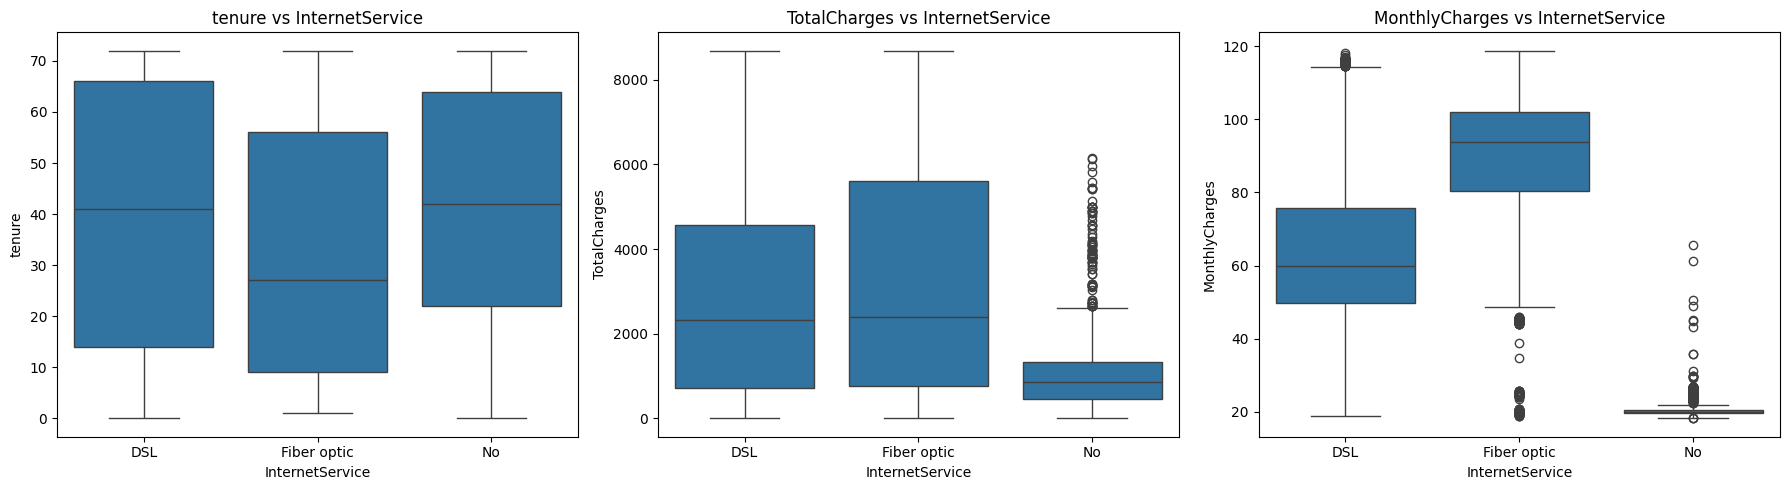

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(
        x="InternetService",
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs InternetService")

plt.tight_layout()
plt.show()

In [162]:
for col in num_cols:
    df[f'categorical_{col}'] = df[col].astype(str)
    df_og[f'categorical_{col}'] = df_og[col].astype(str)
    tf[f'categorical_{col}'] = tf[col].astype(str)

In [163]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})
df_og['Churn'] = df_og['Churn'].map({'No':0, 'Yes':1})

In [164]:
cols = ['StreamingMovies', 'StreamingTV', 'TechSupport',
        'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']

mask = (df[cols] == 'No internet service').all(axis=1)
filtered_df = df[mask]
filtered_df.shape

(142253, 40)

In [165]:
no_int= 100 - ((df.shape[0] - 140727)/ df.shape[0])*100
print(f'{round(no_int,2)}% is having no internet service in {cols}')

23.41% is having no internet service in ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity']


In [166]:
dup = df.duplicated().sum()
print(f'{round(dup,3)} duplicate values exist in our df.')

22 duplicate values exist in our df.


#### removed duplicate values
#### added dominance of no internet service, same binary, trinary, same servicess, fixed contract time, automatic payment

In [167]:
df.drop_duplicates(inplace=True)

In [168]:
df['dominance_of_nointernetservice'] = (df[cols] == 'No internet service').all(axis=1)
df_og['dominance_of_nointernetservice'] = (df_og[cols] == 'No internet service').all(axis=1)
tf['dominance_of_nointernetservice'] = (tf[cols] == 'No internet service').all(axis=1)

In [169]:
df.dominance_of_nointernetservice.value_counts()

dominance_of_nointernetservice
False    458976
True     142239
Name: count, dtype: int64

In [170]:
df['is_fixed_contract_time'] = df['Contract'].apply(lambda x : True if 'year' in x else False)
df_og['is_fixed_contract_time'] = df_og['Contract'].apply(lambda x : True if 'year' in x else False)
tf['is_fixed_contract_time'] = tf['Contract'].apply(lambda x : True if 'year' in x else False)
df['is_automatic_payment'] = df['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)
df_og['is_automatic_payment'] = df_og['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)
tf['is_automatic_payment'] = tf['PaymentMethod'].apply(lambda x : True if 'automatic' in x else False)

In [171]:
# n = len(df.columns)
# ncols = 3
# nrows = math.ceil(n / ncols)

# # violin plots in grid
# fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
# axes = axes.flatten()

# for i, col in enumerate(df.columns):
#     sns.violinplot(y=df[col], ax=axes[i])
#     axes[i].set_title(col)

# # remove empty axes
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

In [172]:
pattern_map = {
    "SeniorCitizen": 'Yes',
    "Dependents": 'Yes',
    "PhoneService": 'No',
    "PaperlessBilling": 'No',
    "all_trinary_same": 1,
    "all_binary_same": 1,
    "dominance_of_nointernetservice": 1
}
df['rarity_factor'] = sum(
    (df[col] == val).astype(int)
    for col, val in pattern_map.items()
)

df_og['rarity_factor'] = sum(
    (df_og[col] == val).astype(int)
    for col, val in pattern_map.items()
)

tf['rarity_factor'] = sum(
    (tf[col] == val).astype(int)
    for col, val in pattern_map.items()
)
n = len(pattern_map)

df['rarity_factor'] = 5 * df['rarity_factor'] / n
df_og['rarity_factor'] = 5 * df_og['rarity_factor'] / n
tf['rarity_factor'] = 5 * tf['rarity_factor'] / n

In [173]:
df_0 = df[df['Churn'] == 0]
df_1 = df[df['Churn'] == 1]

df_0_down = resample(
    df_0,
    replace=False,
    n_samples=150000,
    random_state=42
)

df = pd.concat([df_0_down, df_1])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"downsampled 'No Churn' to 1.5M!")
df.Churn.value_counts()

downsampled 'No Churn' to 1.5M!


Churn
0    150000
1    135674
Name: count, dtype: int64

In [174]:
cols=['gender', 'SeniorCitizen', 'Partner', 'Dependents',        'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
'all_binary_same',
       'all_trinary_same', 'all_same_services',
       'dominance_of_nointernetservice', 'is_fixed_contract_time',
       'is_automatic_payment', 'rarity_factor', 'categorical_tenure', 'categorical_MonthlyCharges', 'categorical_TotalCharges']

In [175]:
encodings = {}

target = "Churn"

for col in cols:
    mapping = df.groupby(col)[target].mean()
    encodings[col] = mapping

    print(f"{col} target encoding:")
    print(mapping.to_dict())
    print("-" * 40)

for col in cols:
    df[col]    = df[col].map(encodings[col])
    df_og[col] = df_og[col].map(encodings[col])
    tf[col]    = tf[col].map(encodings[col])

gender target encoding:
{'Female': 0.4791831466755485, 'Male': 0.4705919751342187}
----------------------------------------
SeniorCitizen target encoding:
{'No': 0.42147185138329396, 'Yes': 0.7579884525541011}
----------------------------------------
Partner target encoding:
{'No': 0.5994197180572725, 'Yes': 0.32488054159622676}
----------------------------------------
Dependents target encoding:
{'No': 0.561053848907327, 'Yes': 0.19798429937433598}
----------------------------------------
PhoneService target encoding:
{'No': 0.386472834791179, 'Yes': 0.48025534441805223}
----------------------------------------
MultipleLines target encoding:
{'No': 0.4096786023611295, 'No phone service': 0.386472834791179, 'Yes': 0.5442770082318217}
----------------------------------------
InternetService target encoding:
{'DSL': 0.264015465341066, 'Fiber optic': 0.6890030226032924, 'No': 0.045005511744255065}
----------------------------------------
OnlineSecurity target encoding:
{'No': 0.6801300623

In [176]:
# # correlations
# spearman_corr = df_og.corr(method="spearman")
# kendall_corr  = df_og.corr(method="pearson")

# # one row, two columns
# fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# # Spearman
# sns.heatmap(
#     spearman_corr.round(2),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     ax=axes[0]
# )
# axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- Before")

# # Pearson
# sns.heatmap(
#     kendall_corr.round(2),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     ax=axes[1],
#     yticklabels=False
# )
# axes[1].set_title("Pearson Correlation (Linear Relationships) -- Before")

# plt.tight_layout()
# # correlations
# spearman_corr = df.corr(method="spearman")
# kendall_corr  = df.corr(method="pearson")

# # one row, two columns
# fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# # Spearman
# sns.heatmap(
#     spearman_corr.round(2),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     ax=axes[0]
# )
# axes[0].set_title("Spearman Correlation (Monotonic Relationships) -- After")

# # Pearson
# sns.heatmap(
#     kendall_corr.round(2),
#     annot=True,
#     fmt=".2f",
#     cmap="coolwarm",
#     center=0,
#     ax=axes[1],
#     yticklabels=False
# )
# axes[1].set_title("Pearson Correlation (Linear Relationships) -- After")

# plt.tight_layout()
# plt.show()

In [177]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'is_auto_payment',
       'paperless_autopay', 'high_monthlycharges', 'high_totalcharges',
       'high_tenure', 'is_male_senior', 'feat_streaming_internet_phone',
       'feat_support_bundle', 'tenure_TotalCharges_ratio',
       'tenure_MonthlyCharges_ratio', 'TotalCharges_tenure_ratio',
       'TotalCharges_MonthlyCharges_ratio', 'MonthlyCharges_tenure_ratio',
       'MonthlyCharges_TotalCharges_ratio', 'all_binary_same',
       'all_trinary_same', 'all_same_services', 'categorical_tenure',
       'categorical_TotalCharges', 'categorical_MonthlyCharges',
       'dominance_of_nointernetservice', 'is_fixed_contract_time',
       'is_automatic_payme

In [178]:
scaler = MinMaxScaler()
scale_cols = ['tenure',
       'MonthlyCharges', 'TotalCharges', 'tenure_TotalCharges_ratio',
       'tenure_MonthlyCharges_ratio', 'TotalCharges_tenure_ratio',
       'TotalCharges_MonthlyCharges_ratio', 'MonthlyCharges_tenure_ratio',
       'MonthlyCharges_TotalCharges_ratio', ]


df[scale_cols] = df[scale_cols].apply(pd.to_numeric, errors='coerce')
tf[scale_cols] = tf[scale_cols].apply(pd.to_numeric, errors='coerce')

In [179]:
df.Churn.value_counts()

Churn
0    150000
1    135674
Name: count, dtype: int64

In [180]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 228539 entries, 0 to 285673
Data columns (total 43 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   gender                             228539 non-null  float64
 1   SeniorCitizen                      228539 non-null  float64
 2   Partner                            228539 non-null  float64
 3   Dependents                         228539 non-null  float64
 4   tenure                             228539 non-null  float64
 5   PhoneService                       228539 non-null  float64
 6   MultipleLines                      228539 non-null  float64
 7   InternetService                    228539 non-null  float64
 8   OnlineSecurity                     228539 non-null  float64
 9   OnlineBackup                       228539 non-null  float64
 10  DeviceProtection                   228539 non-null  float64
 11  TechSupport                        228539 no

In [181]:
target_col = 'Churn'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)
X_train = X_train.clip(-1e6, 1e6)
X_test  = X_test.clip(-1e6, 1e6)


print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
X_train.fillna(-1, inplace=True)
print(X_train.isnull().sum().sum(), X_test.isnull().sum().sum())

6 0
0 0


In [182]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

## CatBoost

In [183]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    cat = CatBoostClassifier(
        iterations=110,
        learning_rate=0.3,
        depth=8,
        eval_metric="AUC",
        verbose=0,
        random_state=42
    )
    
    cat.fit(X_train, y_train)
    
    test_probs = cat.predict_proba(X_test)[:, 1]
    
    # default threshold 0.5
    test_preds = (test_probs >= 0.5).astype(int)
    
    metrics = {
        "fold": fold,
        "test_acc": accuracy_score(y_test, test_preds),
        "test_f1": f1_score(y_test, test_preds),
        "test_roc": roc_auc_score(y_test, test_probs)
    }
    
    fold_results.append(metrics)
fold_df = pd.DataFrame(fold_results)
print(fold_df)
print("\nMean metrics across folds:")
print(fold_df.mean())

   fold  test_acc   test_f1  test_roc
0     1  0.852682  0.850218  0.930075
1     2  0.850074  0.847575  0.928976
2     3  0.848587  0.845834  0.928477
3     4  0.852927  0.849896  0.931512
4     5  0.853642  0.851099  0.930972

Mean metrics across folds:
fold        3.000000
test_acc    0.851583
test_f1     0.848924
test_roc    0.930002
dtype: float64


In [184]:
# model
cat = CatBoostClassifier(
    iterations=110,
    learning_rate=0.3,
    depth=8,
    eval_metric="AUC",
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

# probabilities (MANDATORY for ROC)
train_probs = cat.predict_proba(X_train)[:, 1]
test_probs  = cat.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    row = {
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),

        # FIX: use probabilities
        "train_roc": roc_auc_score(y_train, train_probs),
        "test_roc": roc_auc_score(y_test, test_probs)
    }

    rows.append(row)

thresh_df = pd.DataFrame(rows)
print(thresh_df)

    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.474928  0.474919  0.644001  0.643993   0.939417  0.930972
1        0.05   0.741498  0.741870  0.785276  0.785202   0.939417  0.930972
2        0.10   0.784467  0.781654  0.813330  0.810804   0.939417  0.930972
3        0.15   0.809329  0.803795  0.830252  0.825411   0.939417  0.930972
4        0.20   0.825125  0.819880  0.841044  0.836185   0.939417  0.930972
5        0.25   0.836720  0.830941  0.848814  0.843348   0.939417  0.930972
6        0.30   0.846723  0.838292  0.855464  0.847564   0.939417  0.930972
7        0.35   0.854323  0.845241  0.860134  0.851505   0.939417  0.930972
8        0.40   0.859005  0.849039  0.862099  0.852667   0.939417  0.930972
9        0.45   0.862772  0.852242  0.863160  0.852747   0.939417  0.930972
10       0.50   0.863858  0.853642  0.861464  0.851099   0.939417  0.930972
11       0.55   0.862982  0.852505  0.857372  0.846567   0.939417  0.930972
12       0.6

## XGBoost

In [200]:
# for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
#     X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#     y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


#     xgb = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.06,
#     max_depth=7,
#     random_state=42,
#     objective="binary:logistic",
#     eval_metric="auc",
# )

    
#     xgb.fit(X_train, y_train)
    
#     test_probs = xgb.predict_proba(X_test)[:, 1]
    
#     # default threshold 0.5
#     test_preds = (test_probs >= 0.5).astype(int)
    
#     metrics = {
#         "fold": fold,
#         "test_acc": accuracy_score(y_test, test_preds),
#         "test_f1": f1_score(y_test, test_preds),
#         "test_roc": roc_auc_score(y_test, test_probs)
#     }
    
#     fold_results.append(metrics)
# fold_df = pd.DataFrame(fold_results)
# print(fold_df)
# print("\nMean metrics across folds:")
# print(fold_df.mean())

In [194]:
# xgb = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.06,
#     max_depth=7,
#     random_state=42,
#     objective="binary:logistic",
#     eval_metric="auc",
# )

# xgb.fit(X_train, y_train)

# # probabilities
# train_probs = xgb.predict_proba(X_train)[:, 1]
# test_probs  = xgb.predict_proba(X_test)[:, 1]

# thresholds = np.arange(0.0, 1.01, 0.05)
# rows = []

# for t in thresholds:
#     train_preds = (train_probs >= t).astype(int)
#     test_preds  = (test_probs  >= t).astype(int)

#     row = {
#         "threshold": round(t, 2),
#         "train_acc": accuracy_score(y_train, train_preds),
#         "test_acc": accuracy_score(y_test, test_preds),
#         "train_f1": f1_score(y_train, train_preds),
#         "test_f1": f1_score(y_test, test_preds),
#         "train_roc": roc_auc_score(y_train, train_probs),
#         "test_roc": roc_auc_score(y_test, test_probs)
#     }

#     rows.append(row)

# thresh_df = pd.DataFrame(rows)
# print(thresh_df)

## LGBM

In [195]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.10,
        max_depth=14,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    test_probs = model.predict_proba(X_test)[:, 1]
    
    # default threshold 0.5
    test_preds = (test_probs >= 0.5).astype(int)
    
    metrics = {
        "fold": fold,
        "test_acc": accuracy_score(y_test, test_preds),
        "test_f1": f1_score(y_test, test_preds),
        "test_roc": roc_auc_score(y_test, test_probs)
    }
    
    fold_results.append(metrics)
fold_df = pd.DataFrame(fold_results)
print(fold_df)
print("\nMean metrics across folds:")
print(fold_df.mean())

[LightGBM] [Info] Number of positive: 108539, number of negative: 120000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038877 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2795
[LightGBM] [Info] Number of data points in the train set: 228539, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474926 -> initscore=-0.100382
[LightGBM] [Info] Start training from score -0.100382
[LightGBM] [Info] Number of positive: 108539, number of negative: 120000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2795
[LightGBM] [Info] Number of data points in the train set: 228539, number of used features: 43
[LightGBM] [

In [196]:
# model
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.10,
    max_depth=14,
    random_state=42
)

lgbm.fit(X_train, y_train)

# probabilities
train_probs = lgbm.predict_proba(X_train)[:, 1]
test_probs  = lgbm.predict_proba(X_test)[:, 1]

# thresholds
thresholds = np.arange(0.0, 1.01, 0.05)
rows = []

for t in thresholds:
    train_preds = (train_probs >= t).astype(int)
    test_preds  = (test_probs  >= t).astype(int)

    row = {
        "threshold": round(t, 2),
        "train_acc": accuracy_score(y_train, train_preds),
        "test_acc": accuracy_score(y_test, test_preds),
        "train_f1": f1_score(y_train, train_preds),
        "test_f1": f1_score(y_test, test_preds),
        "train_roc": roc_auc_score(y_train, train_probs),
        "test_roc": roc_auc_score(y_test, test_probs)
    }

    rows.append(row)

thresh_df = pd.DataFrame(rows)
print(thresh_df)

[LightGBM] [Info] Number of positive: 108540, number of negative: 120000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2795
[LightGBM] [Info] Number of data points in the train set: 228540, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.474928 -> initscore=-0.100373
[LightGBM] [Info] Start training from score -0.100373
    threshold  train_acc  test_acc  train_f1   test_f1  train_roc  test_roc
0        0.00   0.474928  0.474919  0.644001  0.643993   0.937084  0.931589
1        0.05   0.737770  0.735972  0.783106  0.781456   0.937084  0.931589
2        0.10   0.783556  0.779413  0.812890  0.809245   0.937084  0.931589
3        0.15   0.808340  0.803427  0.829570  0.825196   0.937084  0.931589
4        0.20   0.823099  0.819425  0.839450  0.835965   0.

In [199]:
# xgb_preds = xgb.predict(X_test)
cat_preds = cat.predict(X_test)
lgb_preds = lgbm.predict(X_test)
stack = np.vstack([ cat_preds, lgb_preds])

# majority vote
final_preds = np.round(stack.mean(axis=0)).astype(int)

# probabilities (average for ROC)
# xgb_prob = xgb.predict_proba(X_test)[:, 1]
cat_prob = cat.predict_proba(X_test)[:, 1]
lgb_prob = lgbm.predict_proba(X_test)[:, 1]

avg_prob = ( (.48*cat_prob)+ (.52*lgb_prob)) 

metrics = {
    "Accuracy": accuracy_score(y_test, final_preds),
    "F1": f1_score(y_test, final_preds),
    "ROC-AUC": roc_auc_score(y_test, avg_prob)
}

print(metrics)

{'Accuracy': 0.8540448769559281, 'F1': 0.8496854552337004, 'ROC-AUC': np.float64(0.9318758513304342)}


In [202]:
tf_id = tf.pop('id')

In [203]:
# predictions (test file tf)
# xgb_preds = xgb.predict(tf)
cat_preds = cat.predict(tf)
lgb_preds = lgbm.predict(tf)

# stack
stack = np.vstack([cat_preds, lgb_preds])

# hard voting
final_preds = np.round(stack.mean(axis=0)).astype(int)

# probabilities (for submission)

cat_prob = cat.predict_proba(tf)[:, 1]
lgb_prob = lgbm.predict_proba(tf)[:, 1]

avg_prob = ( (.48*cat_prob)+ (.52*lgb_prob)) 

In [204]:
submission_ensemble = pd.DataFrame({
    "id": tf_id,
    "Churn": avg_prob   
})

submission_ensemble.to_csv("ensemble_churn_predictions_updated_FE.csv", index=False)